In [2]:
!pip install faker

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker()

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
regions = ['North', 'South', 'East', 'West']

states = {
    'North': ['Delhi', 'Punjab', 'Haryana', 'UP'],
    'South': ['Tamil Nadu', 'Karnataka', 'Kerala', 'Telangana'],
    'East': ['West Bengal', 'Odisha', 'Bihar'],
    'West': ['Maharashtra', 'Gujarat', 'Rajasthan']
}

categories = {
    'Electronics': ['Laptop', 'Mobile', 'Tablet', 'Headphones'],
    'Furniture': ['Chair', 'Table', 'Desk', 'Sofa'],
    'Office Supplies': ['Notebook', 'Pen', 'Printer', 'Paper']
}

segments = ['Consumer', 'Corporate', 'Home Office']

salespersons = [
    'Amit', 'Rahul', 'Karan', 'Sneha', 'Priya',
    'Anjali', 'Vikram', 'Rohit', 'Meena', 'Arjun'
]

data = []

for i in range(10000):

    region = random.choice(regions)
    state = random.choice(states[region])
    category = random.choice(list(categories.keys()))
    product = random.choice(categories[category])

    quantity = random.randint(1,10)
    price = random.randint(100,2000)

    sales = quantity * price
    profit = sales * random.uniform(0.05,0.30)

    data.append([
        i+1,
        fake.date_between(start_date='-2y', end_date='today'),
        region,
        state,
        category,
        product,
        round(sales,2),
        quantity,
        round(profit,2),
        random.choice(segments),
        random.choice(salespersons)
    ])

columns = [
    'Order_ID','Order_Date','Region','State','Product_Category',
    'Product_Name','Sales_Amount','Quantity','Profit',
    'Customer_Segment','Salesperson'
]

sales_df = pd.DataFrame(data,columns=columns)

sales_df.head()

,Order_ID,Order_Date,Region,State,Product_Category,Product_Name,Sales_Amount,Quantity,Profit,Customer_Segment,Salesperson
0,1,2025-12-28,South,Telangana,Office Supplies,Paper,4765,5,1184.47,Consumer,Meena
1,2,2024-11-22,South,Karnataka,Furniture,Table,3336,6,245.48,Home Office,Vikram
2,3,2025-12-29,East,West Bengal,Office Supplies,Pen,8472,8,893.87,Corporate,Priya
3,4,2024-04-19,North,Delhi,Office Supplies,Printer,1855,5,112.96,Consumer,Karan
4,5,2024-11-08,South,Kerala,Electronics,Laptop,5320,10,1436.87,Home Office,Anjali


In [5]:
sales_df.to_csv("sales_dataset.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [6]:
conn = sqlite3.connect("sales_database.db")

sales_df.to_sql("sales",conn,index=False,if_exists="replace")

print("Database Created Successfully")

Database Created Successfully


In [7]:
query = """
SELECT Region,
SUM(Sales_Amount) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""

region_sales = pd.read_sql(query,conn)

region_sales

,Region,Total_Sales
0,East,14706639
1,West,14666776
2,South,14449871
3,North,13895926


In [8]:
query = """
SELECT Product_Category,
SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Product_Category
ORDER BY Total_Profit DESC
"""

category_profit = pd.read_sql(query,conn)

category_profit

,Product_Category,Total_Profit
0,Furniture,3379283.05
1,Electronics,3351673.97
2,Office Supplies,3304003.91


In [9]:
query = """
SELECT strftime('%Y-%m',Order_Date) AS Month,
SUM(Sales_Amount) AS Monthly_Sales
FROM sales
GROUP BY Month
ORDER BY Month
"""

monthly_sales = pd.read_sql(query,conn)

monthly_sales

,Month,Monthly_Sales
0,2024-03,2312224
1,2024-04,2055455
2,2024-05,2436067
3,2024-06,2046144
4,2024-07,2516128
5,2024-08,2339480
6,2024-09,2420492
7,2024-10,2636236
8,2024-11,2587205
9,2024-12,2608532


In [10]:
query = """
SELECT Product_Name,
SUM(Sales_Amount) AS Revenue
FROM sales
GROUP BY Product_Name
ORDER BY Revenue DESC
LIMIT 10
"""

top_products = pd.read_sql(query,conn)

top_products

,Product_Name,Revenue
0,Headphones,5125164
1,Paper,5050453
2,Mobile,4891551
3,Sofa,4879239
4,Chair,4864194
5,Pen,4862543
6,Laptop,4834782
7,Notebook,4780343
8,Printer,4705298
9,Table,4598739


In [11]:
query = """
SELECT Salesperson,
SUM(Sales_Amount) AS Total_Sales,
SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Salesperson
ORDER BY Total_Sales DESC
"""

salesperson_perf = pd.read_sql(query,conn)

salesperson_perf

,Salesperson,Total_Sales,Total_Profit
0,Karan,6107129,1094730.21
1,Rohit,6045216,1067730.67
2,Meena,6010734,1070703.76
3,Rahul,5924342,1019296.11
4,Amit,5830801,1008693.53
5,Sneha,5791972,1003023.26
6,Arjun,5755270,966299.31
7,Anjali,5480098,955664.38
8,Vikram,5405208,924089.60
9,Priya,5368442,924730.10


In [12]:
total_sales = sales_df['Sales_Amount'].sum()

total_profit = sales_df['Profit'].sum()

profit_margin = (total_profit / total_sales) * 100

avg_order_value = sales_df['Sales_Amount'].mean()

print("Total Sales:",round(total_sales,2))
print("Total Profit:",round(total_profit,2))
print("Profit Margin:",round(profit_margin,2),"%")
print("Average Order Value:",round(avg_order_value,2))

Total Sales: 57719212
Total Profit: 10034960.93
Profit Margin: 17.39 %
Average Order Value: 5771.92


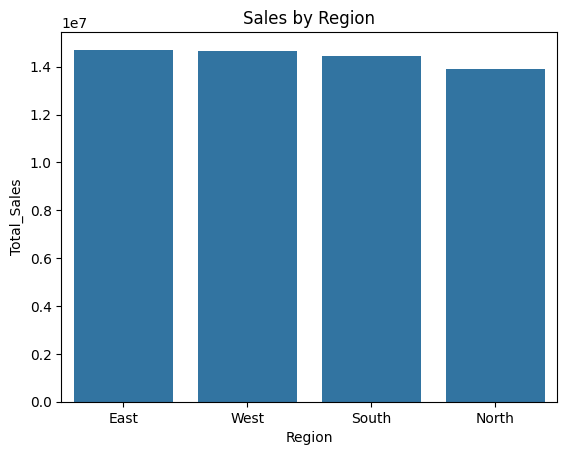

In [13]:
plt.figure()

sns.barplot(data=region_sales,x='Region',y='Total_Sales')

plt.title("Sales by Region")

plt.show()

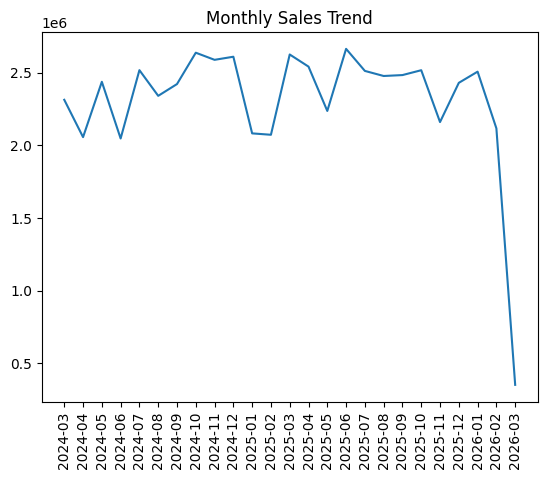

In [14]:
plt.figure()

plt.plot(monthly_sales['Month'],monthly_sales['Monthly_Sales'])

plt.xticks(rotation=90)

plt.title("Monthly Sales Trend")

plt.show()

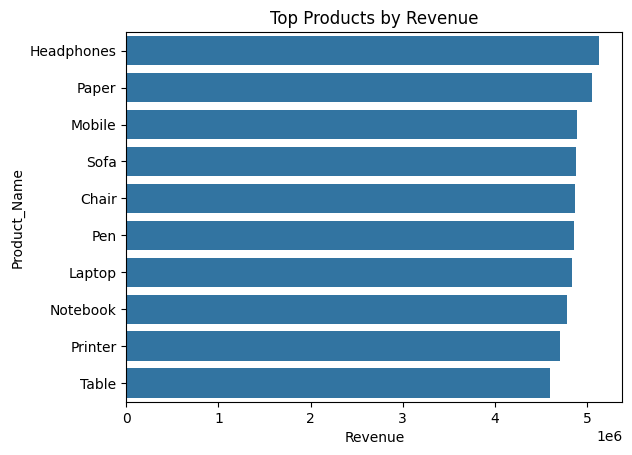

In [15]:
plt.figure()

sns.barplot(data=top_products,x='Revenue',y='Product_Name')

plt.title("Top Products by Revenue")

plt.show()

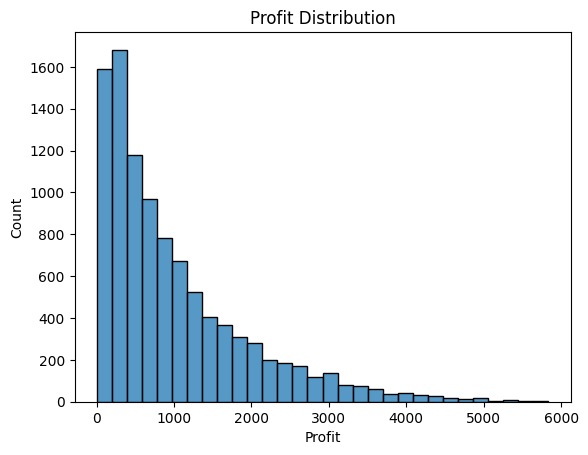

In [16]:
plt.figure()

sns.histplot(sales_df['Profit'],bins=30)

plt.title("Profit Distribution")

plt.show()

In [17]:
region_sales.to_csv("region_sales.csv",index=False)
monthly_sales.to_csv("monthly_sales.csv",index=False)
top_products.to_csv("top_products.csv",index=False)
salesperson_perf.to_csv("salesperson_performance.csv",index=False)

print("Files exported for Power BI")

Files exported for Power BI
